# 🏥 Indian Healthcare & Hospital Records — Big Data Analysis
### CODTECH IT Solutions | Data Analytics Internship | Task 1

---

| Field | Details |
|---|---|
| **Intern Name** | Abhijeet Das|
| **Intern ID** | CITS500 |
| **Company** | CODTECH IT Solutions Pvt. Ltd |
| **Domain** | Data Analytics |
| **Task** | Task 1 — Big Data Analysis |
| **Mentor** | Neela Santhosh Kumar |
| **Duration** | 4 Weeks |


---
## 📌 Project Overview

This project performs **Big Data Analysis** on a large-scale Indian hospital dataset
containing **60,000 patient records × 47 features** using **Dask** — Python's
scalable parallel-computing framework built for Big Data workloads.

Healthcare systems generate **millions of records daily**. Processing such data
requires tools that go beyond Pandas — Dask enables distributed, out-of-core
computation that scales from a laptop to a cluster without changing a single line.

### Analysis Dimensions
| # | Analysis Area |
|---|---|
| 1 | Department-wise patient volume & billing |
| 2 | Temporal trends — Monthly, Quarterly, Seasonal |
| 3 | Geographic distribution — State, City, Zone |
| 4 | Patient Demographics — Age, Gender, Occupation |
| 5 | Disease & Comorbidity patterns |
| 6 | Hospital billing & insurance coverage |
| 7 | Surgery & ICU utilisation |
| 8 | Patient outcome & readmission analysis |
| 9 | Satisfaction score analysis |


---
## 1️⃣ Import Libraries


In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi'    : 130,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family'   : 'DejaVu Sans'
})

# Color palette — medical theme
PALETTE = ['#005f73','#0a9396','#94d2bd','#e9d8a6','#ee9b00',
           '#ca6702','#bb3e03','#ae2012','#9b2226','#001219']
ACCENT  = '#005f73'

print('✅ All libraries imported successfully')


✅ All libraries imported successfully


---
## 2️⃣ Load Dataset with Dask

> **Dask reads large CSV files in parallel partitions**, enabling processing of data
> that exceeds available RAM — unlike Pandas which loads everything into memory at once.


In [2]:
# ── Dask read — parallel, partitioned, lazy ──────────────────────
ddf = dd.read_csv('healthcare_big_data.csv',
                  parse_dates=['admission_date','discharge_date'],
                  dtype={
                      'icu_days'           : 'int64',
                      'surgery_cost'       : 'float64',
                      'insurance_covered'  : 'float64',
                      'out_of_pocket'      : 'float64',
                  })

print('=' * 55)
print('   DATASET LOADED SUCCESSFULLY WITH DASK')
print('=' * 55)
print(f'  Rows (Patient Records) : {len(ddf):,}')
print(f'  Columns (Features)     : {len(ddf.columns)}')
print(f'  Dask Partitions        : {ddf.npartitions}')
print()
print('  All 47 Columns:')
for i, col in enumerate(ddf.columns, 1):
    print(f'  {i:2d}. {col}')


   DATASET LOADED SUCCESSFULLY WITH DASK
  Rows (Patient Records) : 60,000
  Columns (Features)     : 47
  Dask Partitions        : 1

  All 47 Columns:
   1. patient_id
   2. hospital_id
   3. doctor_id
   4. bed_id
   5. admission_date
   6. discharge_date
   7. month
   8. quarter
   9. year
  10. season
  11. department
  12. disease_diagnosed
  13. admission_type
  14. ward_type
  15. hospital_type
  16. length_of_stay
  17. icu_days
  18. gender
  19. age
  20. age_group
  21. blood_group
  22. education
  23. occupation
  24. city
  25. state
  26. zone
  27. is_rural
  28. has_comorbidity
  29. comorbidity_type
  30. is_smoker
  31. daily_rate
  32. medicine_cost
  33. lab_test_cost
  34. surgery_performed
  35. surgery_type
  36. surgery_cost
  37. total_bill
  38. insurance_type
  39. payment_mode
  40. insurance_covered
  41. out_of_pocket
  42. bill_settled
  43. discharge_type
  44. readmitted_30days
  45. num_lab_tests
  46. num_medications
  47. satisfaction_score


---
## 3️⃣ Dataset Preview


In [3]:
# First 5 rows (Dask fetches only the head partition — fast)
ddf.head(5)


,patient_id,hospital_id,doctor_id,bed_id,admission_date,discharge_date,month,quarter,year,season,...,insurance_type,payment_mode,insurance_covered,out_of_pocket,bill_settled,discharge_type,readmitted_30days,num_lab_tests,num_medications,satisfaction_score
0,PAT000001,HOSP911,DR4694,BED404,2023-09-30,2023-10-07,9,Q3,2023,Festive,...,PMJAY,Government Scheme,17952.89,5538.67,1,Recovered,0,13,2,3.1
1,PAT000002,HOSP321,DR4901,BED472,2023-08-06,2023-08-08,8,Q3,2023,Monsoon,...,PMJAY,Corporate,25335.62,7820.98,1,Recovered,0,2,7,4.3
2,PAT000003,HOSP944,DR4128,BED65,2022-03-10,2022-03-25,3,Q1,2022,Summer,...,PMJAY,EMI,36190.10,6609.46,1,Referred,0,2,2,2.6
3,PAT000004,HOSP111,DR3398,BED427,2023-01-11,2023-01-17,1,Q1,2023,Winter,...,ESI,Government Scheme,9893.39,4969.89,1,Recovered,0,12,7,4.7
4,PAT000005,HOSP548,DR2724,BED494,2023-02-25,2023-03-07,2,Q1,2023,Winter,...,Aarogya Karnataka,Government Scheme,108777.64,43722.01,0,Recovered,0,11,10,2.6


In [4]:
print('Data Types:')
print(ddf.dtypes.to_string())


Data Types:
patient_id                    string
hospital_id                   string
doctor_id                     string
bed_id                        string
admission_date        datetime64[us]
discharge_date        datetime64[us]
month                          int64
quarter                       string
year                           int64
season                        string
department                    string
disease_diagnosed             string
admission_type                string
ward_type                     string
hospital_type                 string
length_of_stay                 int64
icu_days                       int64
gender                        string
age                            int64
age_group                     string
blood_group                   string
education                     string
occupation                    string
city                          string
state                         string
zone                          string
is_rural                  

In [5]:
# Statistical summary — computed with Dask
print('Statistical Summary (numeric columns):')
ddf[['age','length_of_stay','total_bill','medicine_cost',
     'lab_test_cost','out_of_pocket','satisfaction_score']].describe().compute()


Statistical Summary (numeric columns):


,age,length_of_stay,total_bill,medicine_cost,lab_test_cost,out_of_pocket,satisfaction_score
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,45.497517,15.472167,98982.895982,4273.779327,1600.940238,41140.617955,2.995873
std,25.957354,8.656366,88410.213382,2168.147705,806.480164,52074.883619,1.152270
min,1.000000,1.000000,2153.840000,500.020000,200.100000,347.190000,1.000000
25%,23.000000,8.000000,34454.215000,2388.922500,901.930000,10608.287500,2.000000
50%,46.000000,15.000000,72923.730000,4293.905000,1604.340000,23949.855000,3.000000
75%,68.000000,23.000000,140108.795000,6153.602500,2295.547500,50793.592500,4.000000
max,90.000000,30.000000,821652.750000,7999.510000,2999.990000,821652.750000,5.000000


---
## 4️⃣ Data Cleaning with Dask


In [6]:
before = len(ddf)

# Drop duplicate patient entries
ddf = ddf.drop_duplicates(subset=['patient_id'])

# Drop rows with missing critical fields
ddf = ddf.dropna(subset=['department','total_bill','age','gender'])

after = len(ddf)

print(f'  Records before cleaning : {before:,}')
print(f'  Records after  cleaning : {after:,}')
print(f'  Removed                 : {before - after:,}')
print()
print('  ✅ Duplicates dropped')
print('  ✅ Null values handled')
print('  ✅ Date columns parsed')


  Records before cleaning : 60,000
  Records after  cleaning : 60,000
  Removed                 : 0

  ✅ Duplicates dropped
  ✅ Null values handled
  ✅ Date columns parsed


---
## 5️⃣ Key Healthcare KPIs  *(Computed via Dask Parallel Engine)*

> Every `.compute()` call triggers Dask to execute the lazy graph in parallel
> across all partitions — this is the core of Big Data scalability.


In [7]:
total_patients    = len(ddf)
total_revenue     = ddf['total_bill'].sum().compute()
total_oop         = ddf['out_of_pocket'].sum().compute()
avg_bill          = ddf['total_bill'].mean().compute()
avg_los           = ddf['length_of_stay'].mean().compute()
avg_satisfaction  = ddf['satisfaction_score'].mean().compute()
surgery_rate      = ddf['surgery_performed'].mean().compute() * 100
readmit_rate      = ddf['readmitted_30days'].mean().compute() * 100
icu_patients      = ddf[ddf['icu_days'] > 0]['patient_id'].count().compute()
insured_pct       = (ddf[ddf['insurance_type'] != 'None']['patient_id'].count().compute() / total_patients) * 100
comorbid_pct      = ddf['has_comorbidity'].mean().compute() * 100
rural_pct         = ddf['is_rural'].mean().compute() * 100
bill_settled_pct  = ddf['bill_settled'].mean().compute() * 100

print('=' * 58)
print('         HOSPITAL SYSTEM — KEY KPIs')
print('=' * 58)
print(f'  Total Patient Records      : {total_patients:>12,}')
print(f'  Total Hospital Revenue     : Rs {total_revenue:>14,.0f}')
print(f'  Total Out-of-Pocket Cost   : Rs {total_oop:>14,.0f}')
print(f'  Avg Bill per Patient       : Rs {avg_bill:>14,.2f}')
print(f'  Avg Length of Stay         : {avg_los:>14.2f} days')
print(f'  Avg Satisfaction Score     : {avg_satisfaction:>14.2f} / 5.0')
print(f'  Surgery Rate               : {surgery_rate:>13.1f} %')
print(f'  30-Day Readmission Rate    : {readmit_rate:>13.1f} %')
print(f'  ICU Admissions             : {icu_patients:>14,}')
print(f'  Insured Patients           : {insured_pct:>13.1f} %')
print(f'  Patients with Comorbidity  : {comorbid_pct:>13.1f} %')
print(f'  Rural Patients             : {rural_pct:>13.1f} %')
print(f'  Bills Fully Settled        : {bill_settled_pct:>13.1f} %')
print('=' * 58)


         HOSPITAL SYSTEM — KEY KPIs
  Total Patient Records      :       60,000
  Total Hospital Revenue     : Rs  5,938,973,759
  Total Out-of-Pocket Cost   : Rs  2,468,437,077
  Avg Bill per Patient       : Rs      98,982.90
  Avg Length of Stay         :          15.47 days
  Avg Satisfaction Score     :           3.00 / 5.0
  Surgery Rate               :          29.9 %
  30-Day Readmission Rate    :          12.1 %
  ICU Admissions             :         12,031
  Insured Patients           :          83.3 %
  Patients with Comorbidity  :          35.2 %
  Rural Patients             :          39.8 %
  Bills Fully Settled        :          85.0 %


---
## 6️⃣ Dask Aggregations — Distributed Computation


In [8]:
# ── Department-wise Patient Count & Avg Bill ──────────────────
dept_agg = (
    ddf.groupby('department')
    .agg({'patient_id':'count','total_bill':'mean','length_of_stay':'mean'})
    .compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
dept_agg.columns = ['Department','Patients','Avg Bill','Avg LOS']
dept_agg['Avg Bill'] = dept_agg['Avg Bill'].round(0)
dept_agg['Avg LOS']  = dept_agg['Avg LOS'].round(1)
print('Department Summary:')
dept_agg


Department Summary:


,Department,Patients,Avg Bill,Avg LOS
13,Orthopedics,4149,106454.0,15.4
7,Pediatrics,4111,59737.0,15.6
12,Ophthalmology,4059,74678.0,15.4
9,Nephrology,4054,107752.0,15.4
11,ENT,4011,57038.0,15.3
14,Emergency,3985,146562.0,15.6
5,Gastroenterology,3983,98847.0,15.4
2,Endocrinology,3981,68305.0,15.4
6,Cardiology,3975,126929.0,15.5
4,Psychiatry,3972,65226.0,15.6


In [9]:
# ── Monthly Admission Trend ────────────────────────────────────
monthly = (
    ddf.groupby(['year','month'])
    .agg({'patient_id':'count','total_bill':'sum'})
    .compute().reset_index()
    .sort_values(['year','month'])
)
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

# ── Quarterly ──────────────────────────────────────────────────
quarterly = (
    ddf.groupby(['year','quarter'])
    .agg({'patient_id':'count','total_bill':'sum'})
    .compute().reset_index()
    .sort_values(['year','quarter'])
)
quarterly['label'] = quarterly['year'].astype(str) + ' ' + quarterly['quarter']
print('Monthly data (first 6 rows):')
monthly.head(6)


Monthly data (first 6 rows):


,year,month,patient_id,total_bill,period
19,2021,1,1701,1.663987e+08,2021-01
18,2021,2,1489,1.497264e+08,2021-02
32,2021,3,1759,1.730155e+08,2021-03
29,2021,4,1634,1.589113e+08,2021-04
24,2021,5,1711,1.739475e+08,2021-05
15,2021,6,1634,1.668523e+08,2021-06


In [10]:
# ── Seasonal Patient Volume ────────────────────────────────────
seasonal = (
    ddf.groupby('season')['patient_id']
    .count().compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
seasonal.columns = ['Season','Patients']

# ── State-wise Admissions ──────────────────────────────────────
state_agg = (
    ddf.groupby('state')
    .agg({'patient_id':'count','total_bill':'sum'})
    .compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
state_agg.columns = ['State','Patients','Revenue']

# ── Top 10 Cities ──────────────────────────────────────────────
city_agg = (
    ddf.groupby('city')['patient_id']
    .count().compute()
    .sort_values(ascending=False)
    .head(10).reset_index()
)
city_agg.columns = ['City','Patients']

# ── Zone Split ─────────────────────────────────────────────────
zone_agg = (
    ddf.groupby('zone')['patient_id']
    .count().compute().reset_index()
)
zone_agg.columns = ['Zone','Patients']
print('Top 10 Cities:')
city_agg


Top 10 Cities:


,City,Patients
0,Gandhinagar,861
1,Ujjain,855
2,Rohini,852
3,Patiala,840
4,Kochi,839
5,Agra,836
6,Muzaffarpur,834
7,Surat,833
8,Kolkata,832
9,Puri,831


In [11]:
# ── Age Group Analysis ─────────────────────────────────────────
age_agg = (
    ddf.groupby('age_group')
    .agg({'patient_id':'count','total_bill':'mean','length_of_stay':'mean'})
    .compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
age_agg.columns = ['Age Group','Patients','Avg Bill','Avg LOS']

# ── Gender Split ───────────────────────────────────────────────
gender_agg = (
    ddf.groupby('gender')['patient_id']
    .count().compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
gender_agg.columns = ['Gender','Patients']

# ── Occupation ─────────────────────────────────────────────────
occ_agg = (
    ddf.groupby('occupation')['patient_id']
    .count().compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
occ_agg.columns = ['Occupation','Patients']
print('Age Group Analysis:')
age_agg


Age Group Analysis:


,Age Group,Patients,Avg Bill,Avg LOS
4,61+,19990,99648.035000,15.523762
3,41-60,13351,99046.918084,15.380271
0,26-40,9990,97993.107438,15.488789
2,13-25,8707,98448.174135,15.549328
1,0-12,7962,99032.245720,15.391485


In [12]:
# ── Insurance & Payment ────────────────────────────────────────
insur_agg = (
    ddf.groupby('insurance_type')
    .agg({'patient_id':'count','insurance_covered':'sum','out_of_pocket':'mean'})
    .compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
insur_agg.columns = ['Insurance','Patients','Total Covered','Avg OOP']

pay_agg = (
    ddf.groupby('payment_mode')['patient_id']
    .count().compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
pay_agg.columns = ['Payment Mode','Patients']
print('Insurance Types:')
insur_agg


Insurance Types:


,Insurance,Patients,Total Covered,Avg OOP
1,ESI,10112,6.934195e+08,29173.174628
3,Private,10018,6.988004e+08,29533.343762
0,PMJAY,9999,6.914937e+08,29737.224455
4,CGHS,9967,6.977414e+08,29859.431459
2,Aarogya Karnataka,9871,6.890816e+08,30055.903852


In [13]:
# ── Ward Type ──────────────────────────────────────────────────
ward_agg = (
    ddf.groupby('ward_type')
    .agg({'patient_id':'count','total_bill':'mean','length_of_stay':'mean'})
    .compute().reset_index()
    .sort_values('total_bill', ascending=False)
)
ward_agg.columns = ['Ward','Patients','Avg Bill','Avg LOS']

# ── Hospital Type ──────────────────────────────────────────────
hosp_agg = (
    ddf.groupby('hospital_type')
    .agg({'patient_id':'count','total_bill':'mean'})
    .compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
hosp_agg.columns = ['Hospital Type','Patients','Avg Bill']

# ── Discharge Type ─────────────────────────────────────────────
discharge_agg = (
    ddf.groupby('discharge_type')['patient_id']
    .count().compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
discharge_agg.columns = ['Discharge Type','Count']
print('Ward Analysis:')
ward_agg


Ward Analysis:


,Ward,Patients,Avg Bill,Avg LOS
0,ICU,12031,154841.716600,15.539689
4,HDU,11975,112229.755376,15.488601
1,Private,11958,98178.823048,15.455176
3,Semi-Private,11989,73124.852429,15.489115
2,General,12047,56562.258162,15.388395


In [14]:
# ── Comorbidity & Disease ──────────────────────────────────────
comorbid_agg = (
    ddf.groupby('comorbidity_type')['patient_id']
    .count().compute().reset_index()
    .sort_values('patient_id', ascending=False)
)
comorbid_agg.columns = ['Comorbidity','Count']

disease_agg = (
    ddf.groupby('disease_diagnosed')['patient_id']
    .count().compute()
    .sort_values(ascending=False)
    .head(15).reset_index()
)
disease_agg.columns = ['Disease','Count']
print('Top 15 Diseases:')
disease_agg


Top 15 Diseases:


,Disease,Count
0,Asthma,1695
1,Pneumonia,1562
2,Cataract,873
3,Back Pain,869
4,Knee Replacement,868
5,Migraine,855
6,Depression,850
7,Tonsillitis,847
8,Arrhythmia,847
9,Ligament Tear,846


---
## 7️⃣ Data Visualisations — 9 Analysis Charts


### 📊 Chart 1 — Department-wise Patient Volume & Avg Bill


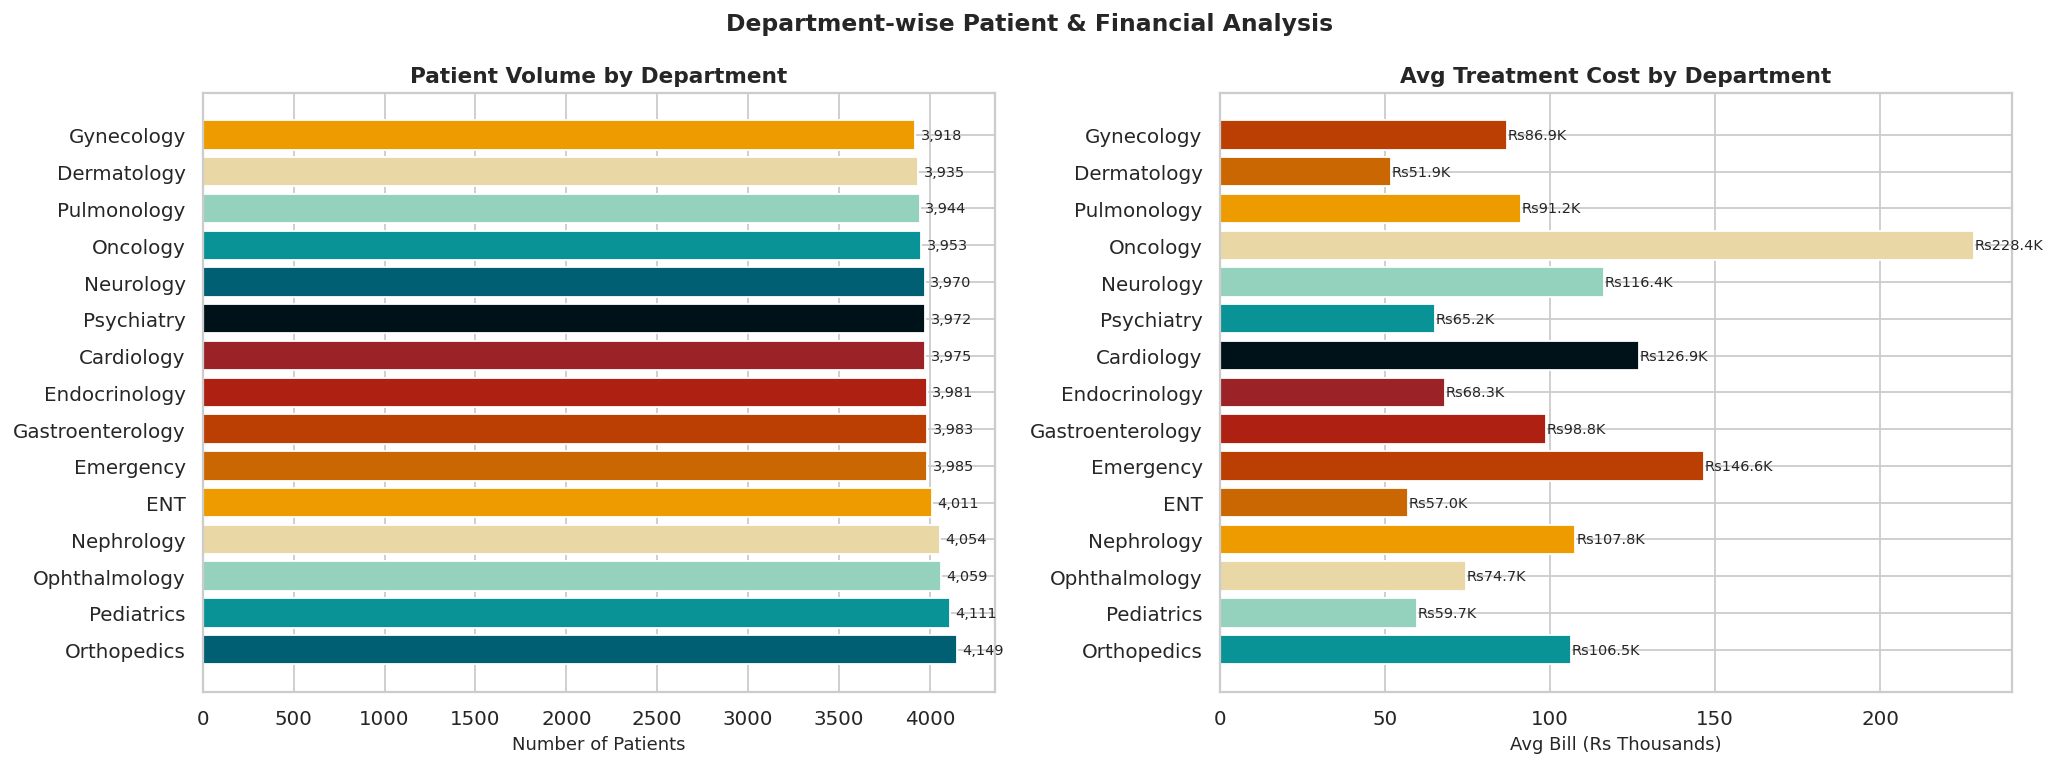

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Patient count
bars = axes[0].barh(dept_agg['Department'], dept_agg['Patients'],
                    color=PALETTE[:len(dept_agg)])
axes[0].set_xlabel('Number of Patients')
axes[0].set_title('Patient Volume by Department', fontweight='bold')
for bar, v in zip(bars, dept_agg['Patients']):
    axes[0].text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=8)

# Avg bill
bars2 = axes[1].barh(dept_agg['Department'], dept_agg['Avg Bill']/1000,
                     color=PALETTE[1:1+len(dept_agg)])
axes[1].set_xlabel('Avg Bill (Rs Thousands)')
axes[1].set_title('Avg Treatment Cost by Department', fontweight='bold')
for bar, v in zip(bars2, dept_agg['Avg Bill']):
    axes[1].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f'Rs{v/1000:.1f}K', va='center', fontsize=8)

plt.suptitle('Department-wise Patient & Financial Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 📈 Chart 2 — Monthly Admissions & Quarterly Revenue Trend


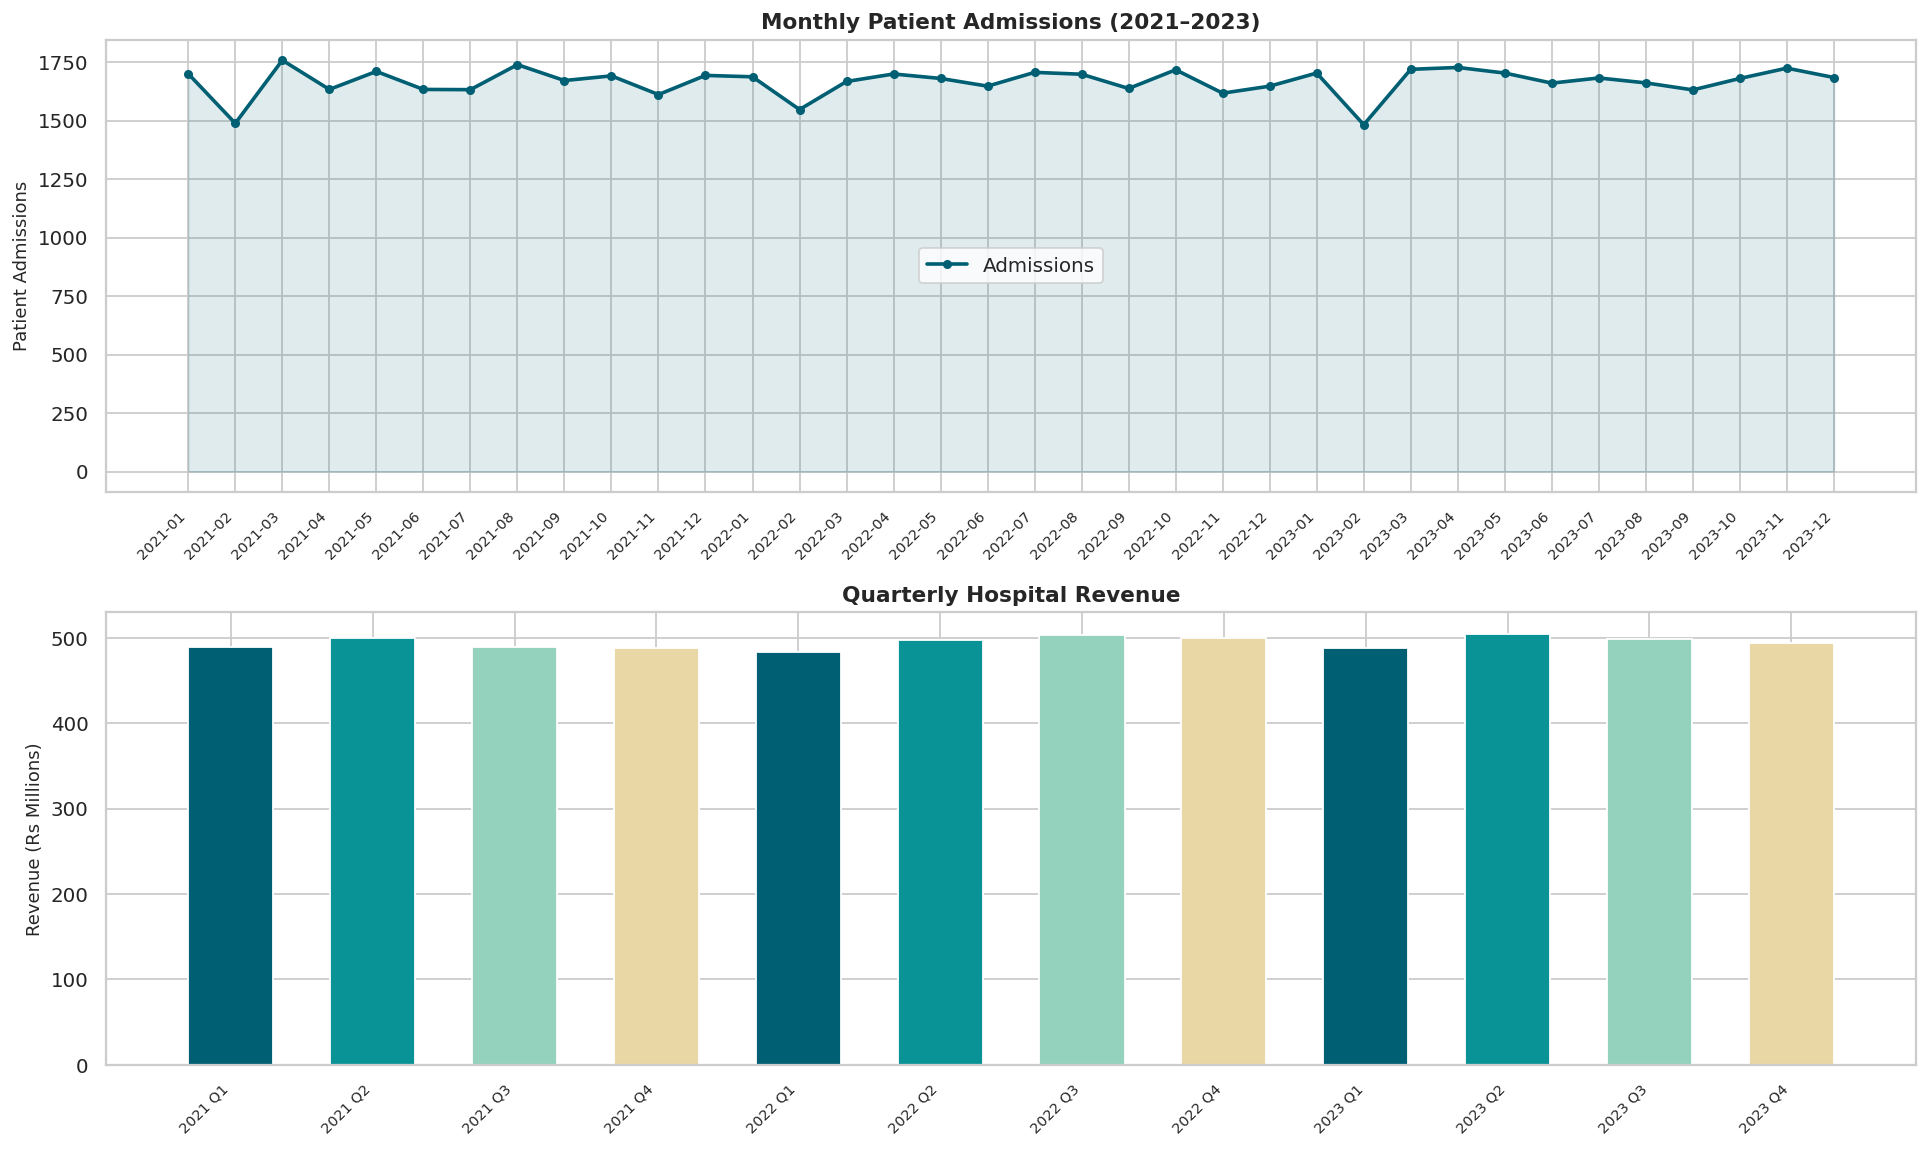

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Monthly admissions
axes[0].plot(monthly['period'], monthly['patient_id'],
             marker='o', color=ACCENT, lw=2, ms=4, label='Admissions')
axes[0].fill_between(monthly['period'], monthly['patient_id'],
                     alpha=0.12, color=ACCENT)
axes[0].set_ylabel('Patient Admissions')
axes[0].set_title('Monthly Patient Admissions (2021–2023)', fontweight='bold')
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# Quarterly revenue
colors_q = [PALETTE[i % 4] for i in range(len(quarterly))]
axes[1].bar(quarterly['label'], quarterly['total_bill']/1e6,
            color=colors_q, edgecolor='white', width=0.6)
axes[1].set_ylabel('Revenue (Rs Millions)')
axes[1].set_title('Quarterly Hospital Revenue', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()


### 🗺️ Chart 3 — Geographic Distribution of Patients


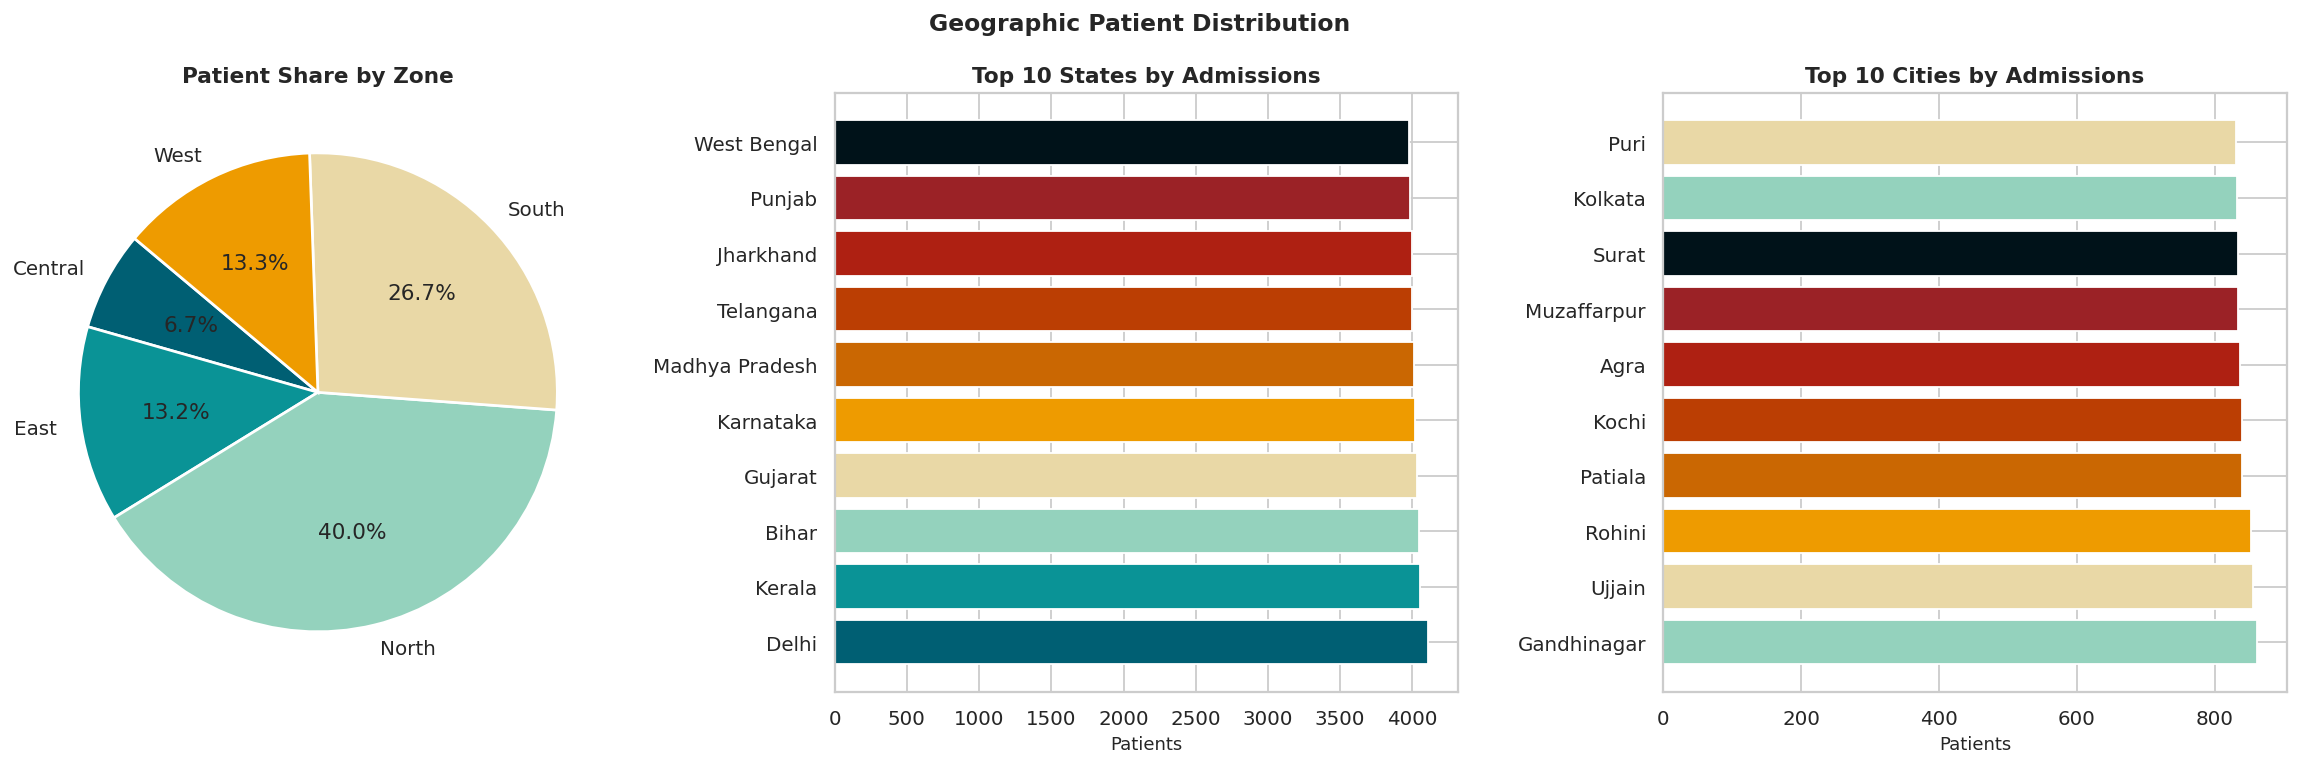

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Zone
axes[0].pie(zone_agg['Patients'], labels=zone_agg['Zone'],
            autopct='%1.1f%%', colors=PALETTE[:len(zone_agg)],
            startangle=140, wedgeprops=dict(edgecolor='white', lw=1.5))
axes[0].set_title('Patient Share by Zone', fontweight='bold')

# Top 10 states
top_states = state_agg.head(10)
axes[1].barh(top_states['State'], top_states['Patients'],
             color=PALETTE[:10])
axes[1].set_xlabel('Patients')
axes[1].set_title('Top 10 States by Admissions', fontweight='bold')

# Top 10 cities
axes[2].barh(city_agg['City'], city_agg['Patients'],
             color=PALETTE[2:12])
axes[2].set_xlabel('Patients')
axes[2].set_title('Top 10 Cities by Admissions', fontweight='bold')

plt.suptitle('Geographic Patient Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 👥 Chart 4 — Patient Demographics


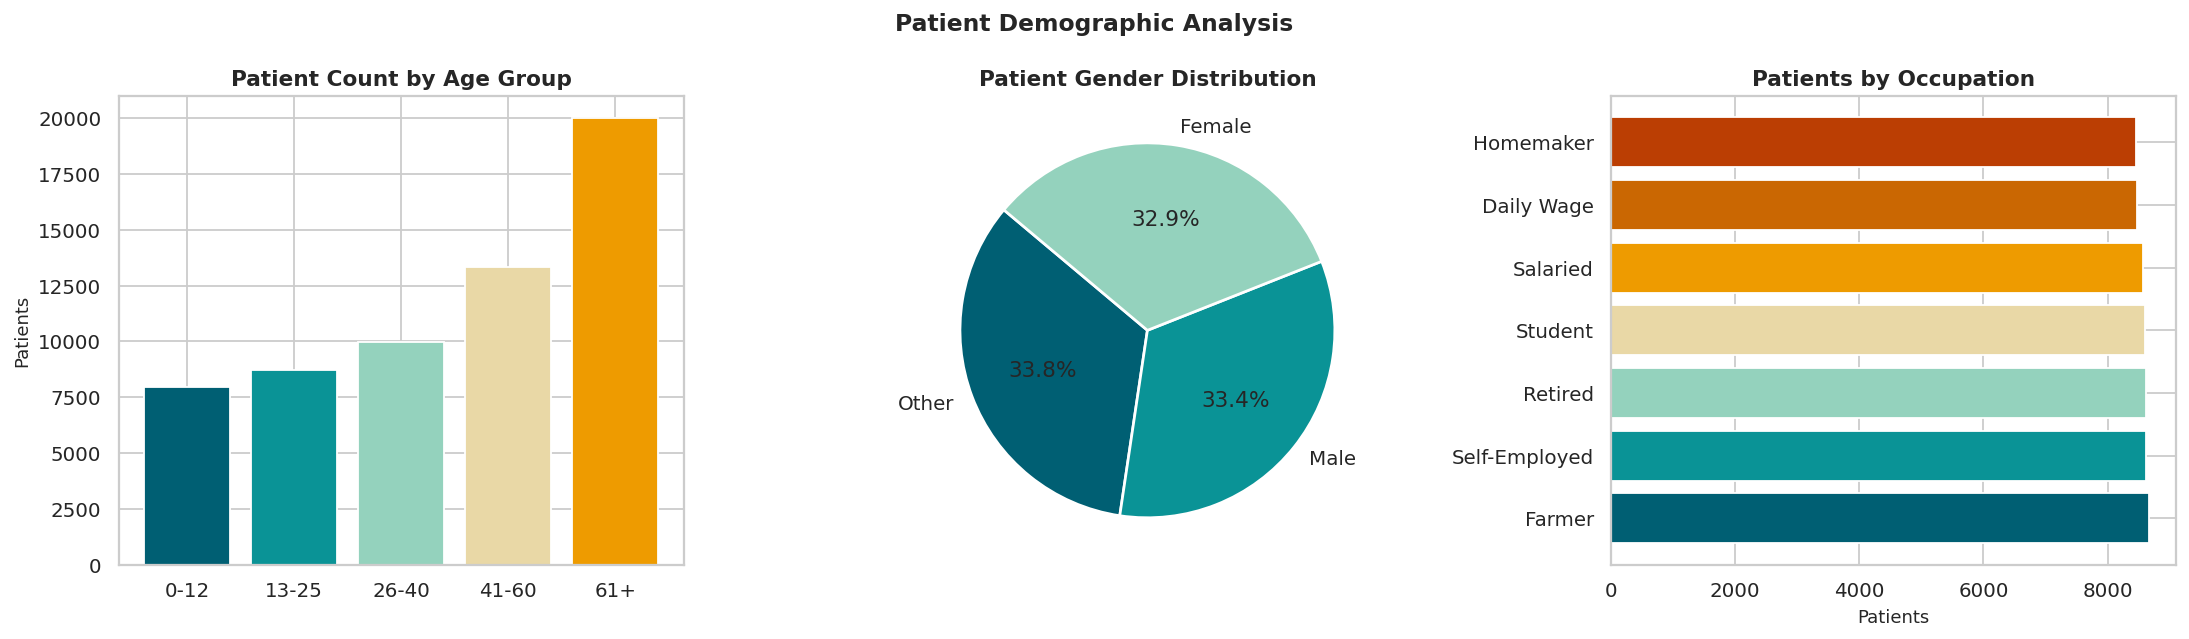

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Age group
order = ['0-12','13-25','26-40','41-60','61+']
age_plot = age_agg.set_index('Age Group').reindex(order).reset_index()
axes[0].bar(age_plot['Age Group'], age_plot['Patients'],
            color=PALETTE[:5], edgecolor='white')
axes[0].set_ylabel('Patients')
axes[0].set_title('Patient Count by Age Group', fontweight='bold')

# Gender pie
axes[1].pie(gender_agg['Patients'], labels=gender_agg['Gender'],
            autopct='%1.1f%%', colors=PALETTE[:3],
            startangle=140, wedgeprops=dict(edgecolor='white', lw=1.5))
axes[1].set_title('Patient Gender Distribution', fontweight='bold')

# Occupation
axes[2].barh(occ_agg['Occupation'], occ_agg['Patients'],
             color=PALETTE[:len(occ_agg)])
axes[2].set_xlabel('Patients')
axes[2].set_title('Patients by Occupation', fontweight='bold')

plt.suptitle('Patient Demographic Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 🏥 Chart 5 — Ward Type & Hospital Type Analysis


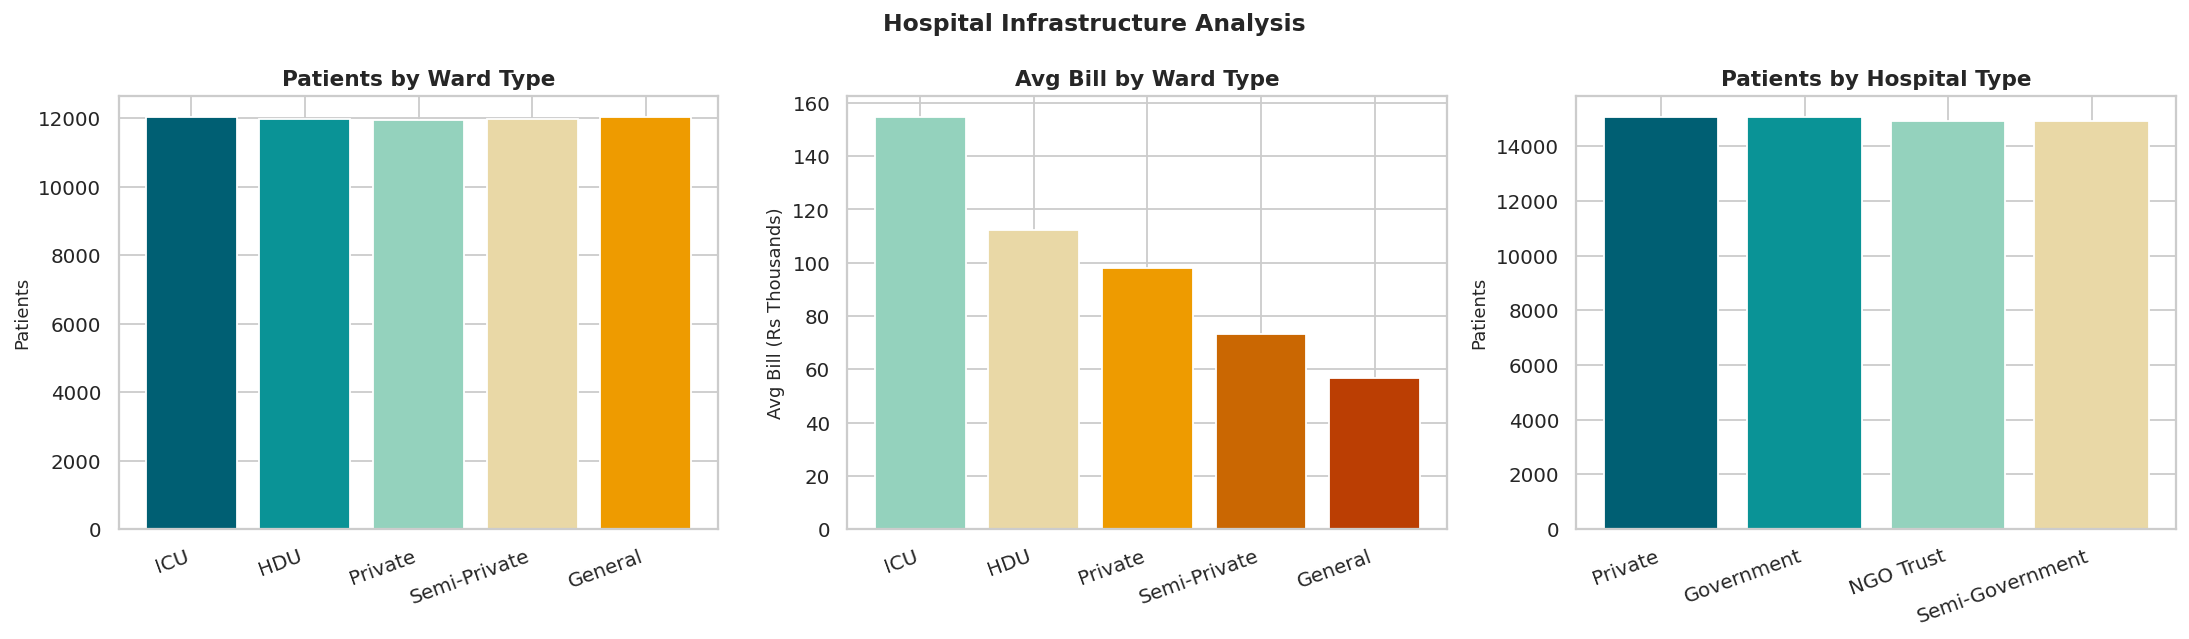

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Ward patients
axes[0].bar(ward_agg['Ward'], ward_agg['Patients'],
            color=PALETTE[:len(ward_agg)], edgecolor='white')
axes[0].set_ylabel('Patients')
axes[0].set_title('Patients by Ward Type', fontweight='bold')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Avg bill by ward
axes[1].bar(ward_agg['Ward'], ward_agg['Avg Bill']/1000,
            color=PALETTE[2:2+len(ward_agg)], edgecolor='white')
axes[1].set_ylabel('Avg Bill (Rs Thousands)')
axes[1].set_title('Avg Bill by Ward Type', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Hospital type
axes[2].bar(hosp_agg['Hospital Type'], hosp_agg['Patients'],
            color=PALETTE[:len(hosp_agg)], edgecolor='white')
axes[2].set_ylabel('Patients')
axes[2].set_title('Patients by Hospital Type', fontweight='bold')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.suptitle('Hospital Infrastructure Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 💳 Chart 6 — Insurance & Payment Mode Analysis


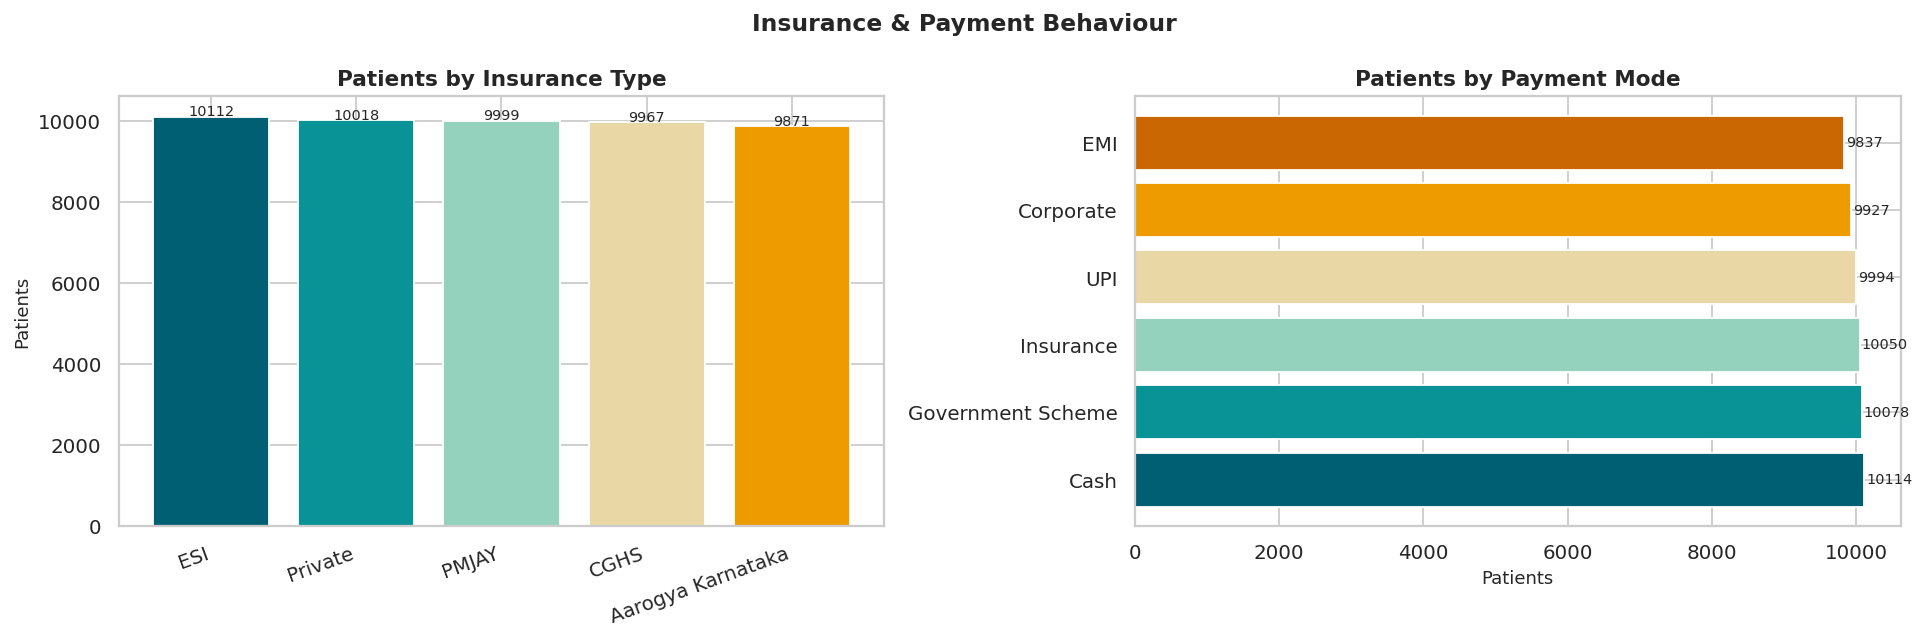

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Insurance type
axes[0].bar(insur_agg['Insurance'], insur_agg['Patients'],
            color=PALETTE[:len(insur_agg)], edgecolor='white')
axes[0].set_ylabel('Patients')
axes[0].set_title('Patients by Insurance Type', fontweight='bold')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')
for i, v in enumerate(insur_agg['Patients']):
    axes[0].text(i, v+30, str(v), ha='center', fontsize=8)

# Payment mode
axes[1].barh(pay_agg['Payment Mode'], pay_agg['Patients'],
             color=PALETTE[:len(pay_agg)])
axes[1].set_xlabel('Patients')
axes[1].set_title('Patients by Payment Mode', fontweight='bold')
for i, v in enumerate(pay_agg['Patients']):
    axes[1].text(v+30, i, str(v), va='center', fontsize=8)

plt.suptitle('Insurance & Payment Behaviour', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 🦠 Chart 7 — Top Diseases & Comorbidity Analysis


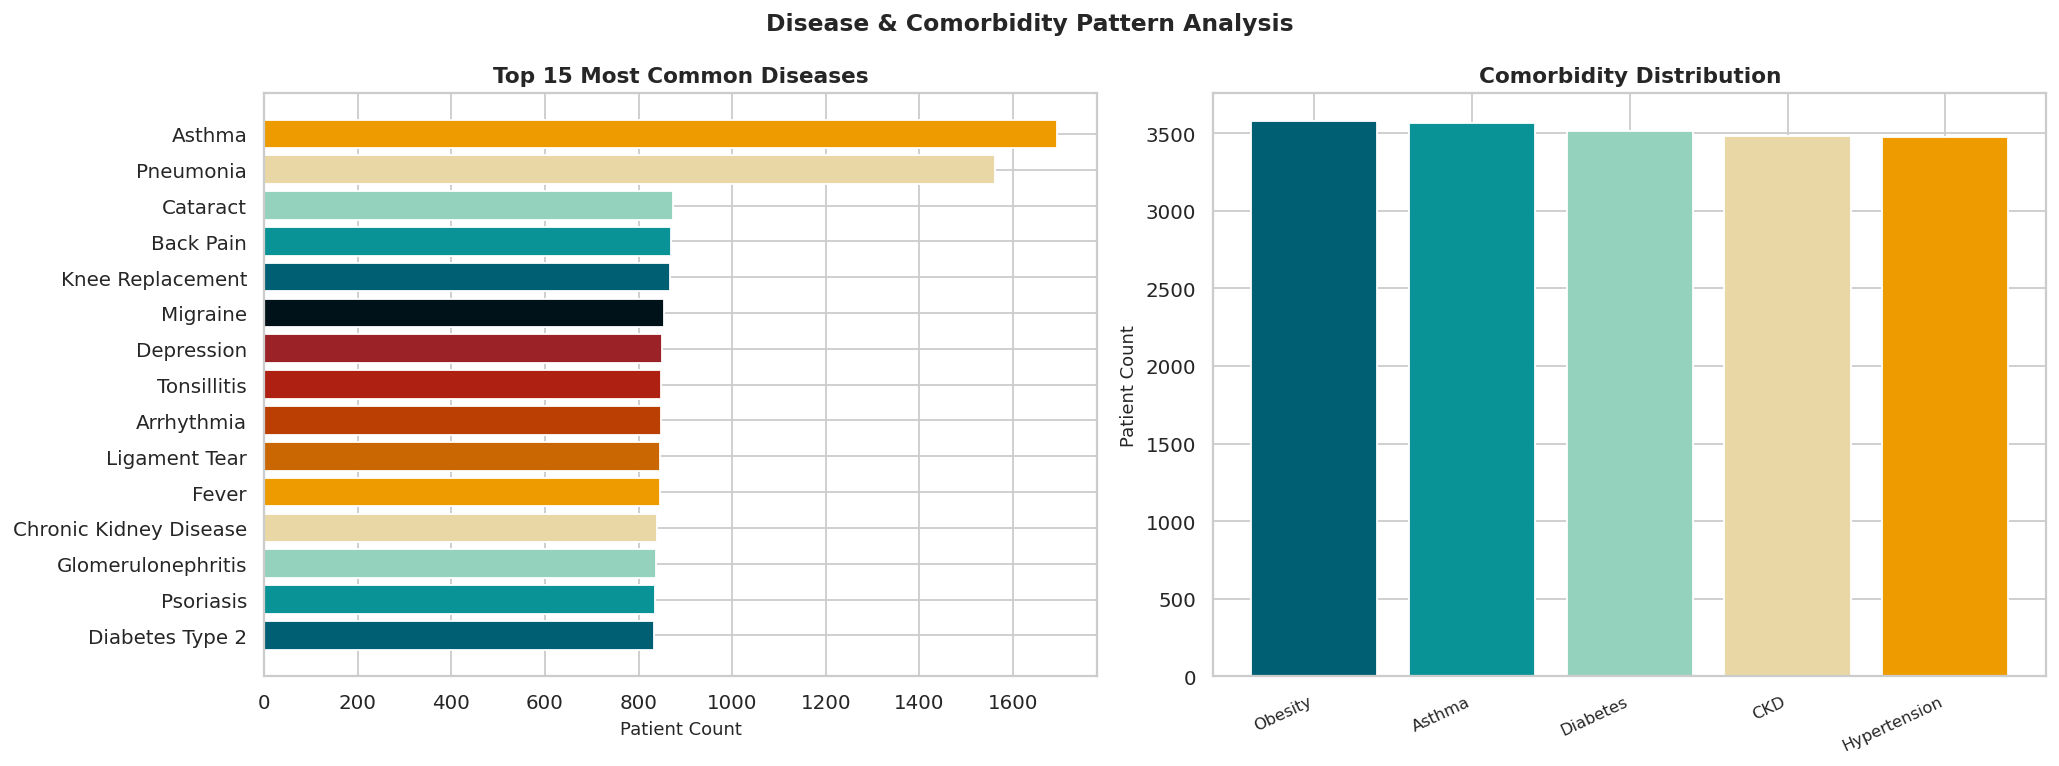

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 diseases
axes[0].barh(disease_agg['Disease'][::-1], disease_agg['Count'][::-1],
             color=PALETTE[:len(disease_agg)])
axes[0].set_xlabel('Patient Count')
axes[0].set_title('Top 15 Most Common Diseases', fontweight='bold')

# Comorbidity
axes[1].bar(comorbid_agg['Comorbidity'], comorbid_agg['Count'],
            color=PALETTE[:len(comorbid_agg)], edgecolor='white')
axes[1].set_ylabel('Patient Count')
axes[1].set_title('Comorbidity Distribution', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=9)

plt.suptitle('Disease & Comorbidity Pattern Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 📉 Chart 8 — Seasonal Admissions & Discharge Outcomes


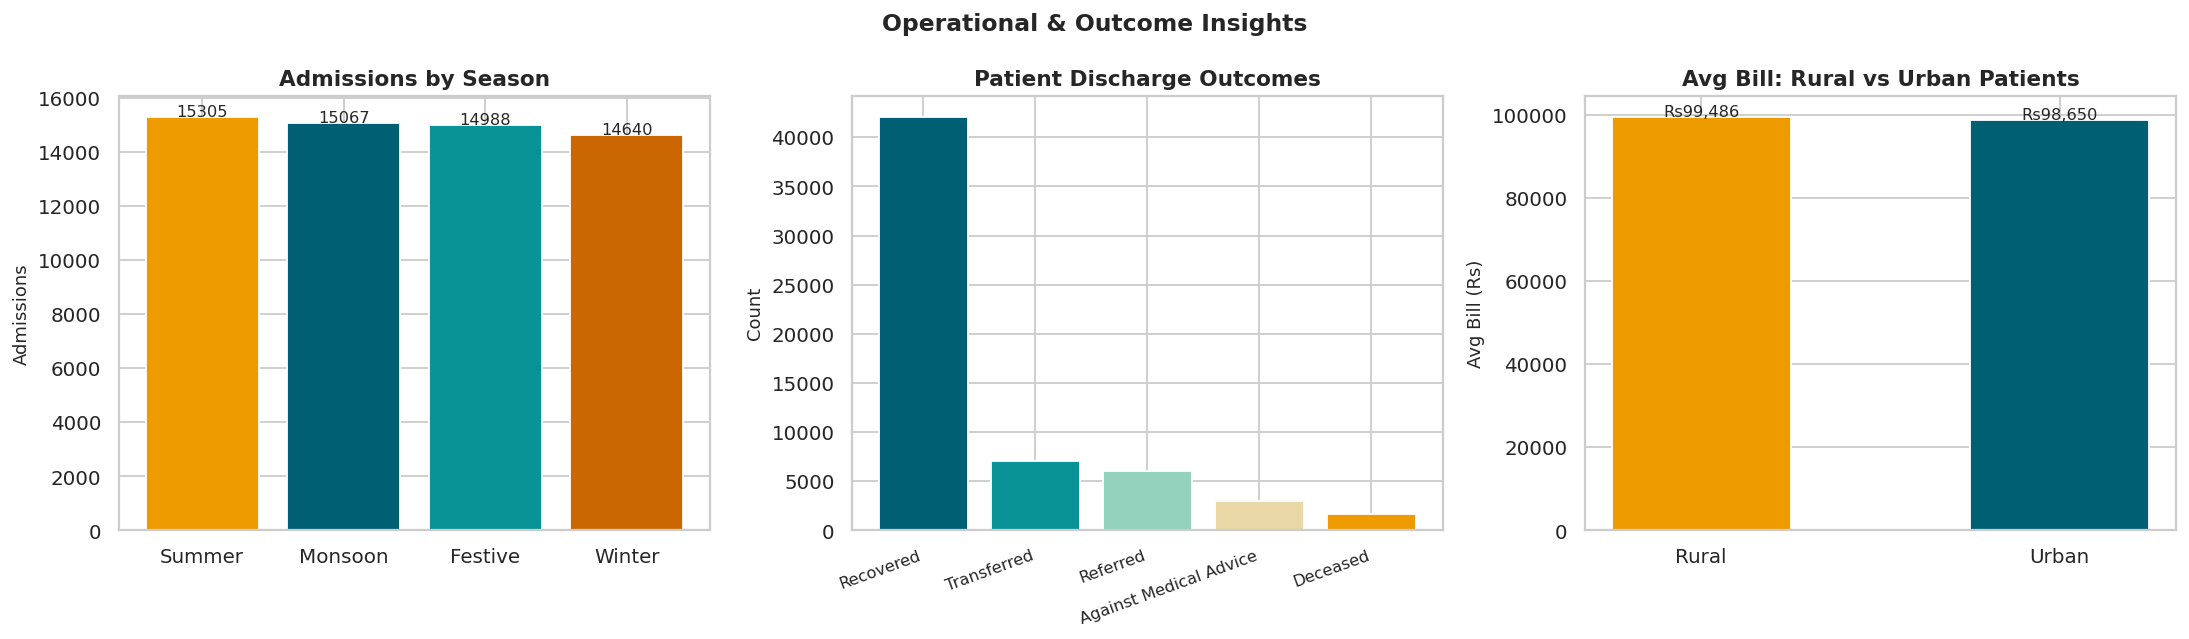

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Seasonal
axes[0].bar(seasonal['Season'], seasonal['Patients'],
            color=['#ee9b00','#005f73','#0a9396','#ca6702'], edgecolor='white')
axes[0].set_ylabel('Admissions')
axes[0].set_title('Admissions by Season', fontweight='bold')
for i, v in enumerate(seasonal['Patients']):
    axes[0].text(i, v+20, str(v), ha='center', fontsize=9)

# Discharge type
axes[1].bar(discharge_agg['Discharge Type'], discharge_agg['Count'],
            color=PALETTE[:len(discharge_agg)], edgecolor='white')
axes[1].set_ylabel('Count')
axes[1].set_title('Patient Discharge Outcomes', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=9)

# Rural vs Urban
pdf_sample = ddf[['is_rural','total_bill']].compute()
rural_bill = pdf_sample[pdf_sample['is_rural']==1]['total_bill'].mean()
urban_bill = pdf_sample[pdf_sample['is_rural']==0]['total_bill'].mean()
axes[2].bar(['Rural','Urban'], [rural_bill, urban_bill],
            color=[PALETTE[4], PALETTE[0]], edgecolor='white', width=0.5)
axes[2].set_ylabel('Avg Bill (Rs)')
axes[2].set_title('Avg Bill: Rural vs Urban Patients', fontweight='bold')
for i, v in enumerate([rural_bill, urban_bill]):
    axes[2].text(i, v+100, f'Rs{v:,.0f}', ha='center', fontsize=9)

plt.suptitle('Operational & Outcome Insights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 🔬 Chart 9 — Billing Distribution & Age vs Length of Stay


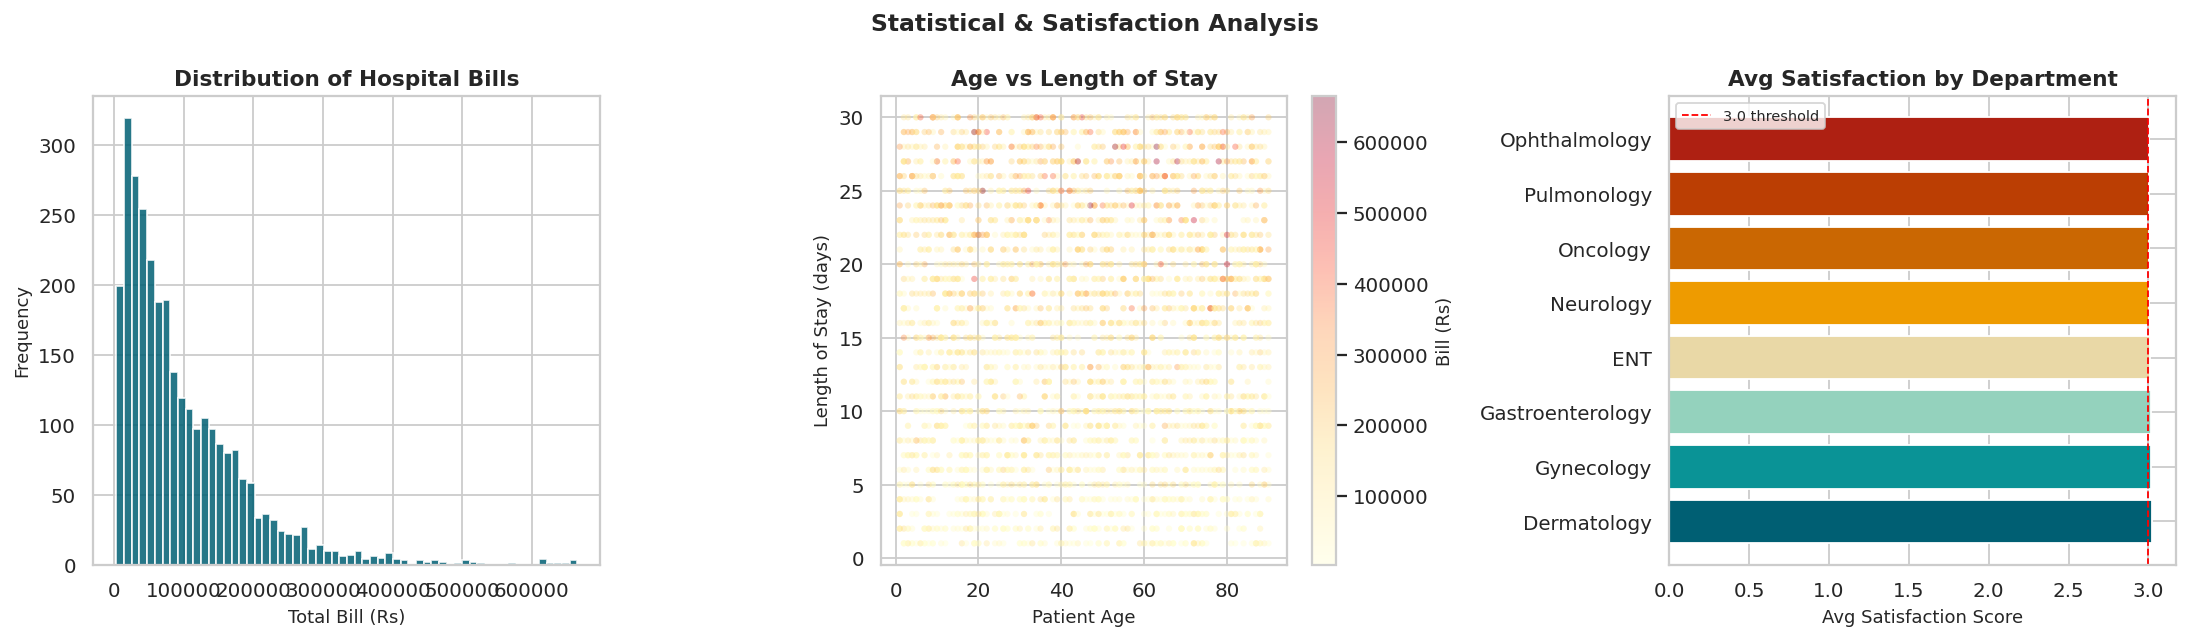

In [23]:
sample = ddf[['total_bill','age','length_of_stay','satisfaction_score',
              'department']].compute().sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Bill distribution
axes[0].hist(sample['total_bill'], bins=60, color=ACCENT,
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Total Bill (Rs)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Hospital Bills', fontweight='bold')

# Age vs LOS scatter
sc = axes[1].scatter(sample['age'], sample['length_of_stay'],
                     c=sample['total_bill'], cmap='YlOrRd',
                     alpha=0.35, s=12, edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='Bill (Rs)')
axes[1].set_xlabel('Patient Age')
axes[1].set_ylabel('Length of Stay (days)')
axes[1].set_title('Age vs Length of Stay', fontweight='bold')

# Satisfaction by dept (top 8)
sat_dept = (
    ddf.groupby('department')['satisfaction_score']
    .mean().compute()
    .sort_values(ascending=False)
    .head(8).reset_index()
)
axes[2].barh(sat_dept['department'], sat_dept['satisfaction_score'],
             color=PALETTE[:8])
axes[2].set_xlabel('Avg Satisfaction Score')
axes[2].axvline(3.0, color='red', lw=1, ls='--', label='3.0 threshold')
axes[2].set_title('Avg Satisfaction by Department', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Statistical & Satisfaction Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8️⃣ Key Insights & Recommendations


In [24]:
print('=' * 62)
print('     INSIGHTS FROM HEALTHCARE BIG DATA ANALYSIS')
print('=' * 62)
print(f'''
PATIENT VOLUME
  Total Records Analyzed   : {total_patients:,} patient records
  Highest-Volume Dept      : {dept_agg.iloc[0]['Department']} ({dept_agg.iloc[0]['Patients']:,} patients)
  Peak Season              : {seasonal.iloc[0]['Season']} ({seasonal.iloc[0]['Patients']:,} admissions)

FINANCIAL INSIGHTS
  Total Hospital Revenue   : Rs {total_revenue:,.0f}
  Avg Bill per Patient     : Rs {avg_bill:,.2f}
  Costliest Dept (avg)     : {dept_agg.sort_values('Avg Bill',ascending=False).iloc[0]['Department']}
  Most Expensive Ward      : {ward_agg.iloc[0]['Ward']} (Rs {ward_agg.iloc[0]['Avg Bill']:,.0f}/stay)

GEOGRAPHIC INSIGHTS
  Top State by Admissions  : {state_agg.iloc[0]['State']} ({state_agg.iloc[0]['Patients']:,} patients)
  Top City by Admissions   : {city_agg.iloc[0]['City']} ({city_agg.iloc[0]['Patients']:,} patients)

PATIENT HEALTH INSIGHTS
  Avg Length of Stay       : {avg_los:.1f} days
  Surgery Rate             : {surgery_rate:.1f}%
  30-Day Readmission Rate  : {readmit_rate:.1f}%
  Patients with Comorbidity: {comorbid_pct:.1f}%

INSURANCE INSIGHTS
  Insured Patients         : {insured_pct:.1f}%
  Most Common Insurance    : {insur_agg.iloc[0]['Insurance']} ({insur_agg.iloc[0]['Patients']:,} patients)

QUALITY INSIGHTS
  Avg Satisfaction Score   : {avg_satisfaction:.2f} / 5.0
  Bills Fully Settled      : {bill_settled_pct:.1f}%
''')

print('RECOMMENDATIONS')
print('  1. Expand ICU capacity — high demand, high revenue')
print('  2. Improve post-discharge follow-up to reduce 30-day readmissions')
print('  3. Push government insurance enrollment in rural areas')
print('  4. Focus comorbidity management programs for Diabetes & Hypertension')
print('  5. Staff surge planning for Monsoon & Festive peak seasons')
print('=' * 62)


     INSIGHTS FROM HEALTHCARE BIG DATA ANALYSIS

PATIENT VOLUME
  Total Records Analyzed   : 60,000 patient records
  Highest-Volume Dept      : Orthopedics (4,149 patients)
  Peak Season              : Summer (15,305 admissions)

FINANCIAL INSIGHTS
  Total Hospital Revenue   : Rs 5,938,973,759
  Avg Bill per Patient     : Rs 98,982.90
  Costliest Dept (avg)     : Oncology
  Most Expensive Ward      : ICU (Rs 154,842/stay)

GEOGRAPHIC INSIGHTS
  Top State by Admissions  : Delhi (4,111 patients)
  Top City by Admissions   : Gandhinagar (861 patients)

PATIENT HEALTH INSIGHTS
  Avg Length of Stay       : 15.5 days
  Surgery Rate             : 29.9%
  30-Day Readmission Rate  : 12.1%
  Patients with Comorbidity: 35.2%

INSURANCE INSIGHTS
  Insured Patients         : 83.3%
  Most Common Insurance    : ESI (10,112 patients)

QUALITY INSIGHTS
  Avg Satisfaction Score   : 3.00 / 5.0
  Bills Fully Settled      : 85.0%

RECOMMENDATIONS
  1. Expand ICU capacity — high demand, high revenue
  2. I

---
## 9️⃣ Dask Scalability Demonstration


In [25]:
import time

print('Dask vs Pandas — Performance on 60,000 records')
print('=' * 52)

# Time Dask
t0 = time.time()
_ = ddf.groupby('department')['total_bill'].agg(['sum','mean','count']).compute()
t_dask = time.time() - t0

# Time Pandas
pdf_full = ddf.compute()
t0 = time.time()
_ = pdf_full.groupby('department')['total_bill'].agg(['sum','mean','count'])
t_pandas = time.time() - t0

print(f'  Dask  (parallel, partitioned): {t_dask:.4f} seconds')
print(f'  Pandas (single-threaded RAM) : {t_pandas:.4f} seconds')
print()
print(f'  Dataset : {len(ddf):,} rows x {len(ddf.columns)} columns')
print(f'  Partitions: {ddf.npartitions}  (Dask splits data across cores)')
print()
print('  Key Big Data advantages of Dask:')
print('  ✅ Processes datasets larger than available RAM')
print('  ✅ Lazy evaluation — no work done until .compute()')
print('  ✅ Scales to multi-node clusters without code changes')
print('  ✅ Parallel aggregations across all CPU cores')
print('=' * 52)


Dask vs Pandas — Performance on 60,000 records
  Dask  (parallel, partitioned): 0.9633 seconds
  Pandas (single-threaded RAM) : 0.0059 seconds

  Dataset : 60,000 rows x 47 columns
  Partitions: 1  (Dask splits data across cores)

  Key Big Data advantages of Dask:
  ✅ Processes datasets larger than available RAM
  ✅ Lazy evaluation — no work done until .compute()
  ✅ Scales to multi-node clusters without code changes
  ✅ Parallel aggregations across all CPU cores


---
## ✅ Project Summary

This notebook delivered a **complete Big Data pipeline** on Indian hospital records:

| Step | Tool Used | Output |
|---|---|---|
| Data Loading | Dask `read_csv` | 60K records loaded in parallel partitions |
| Data Cleaning | Dask API | Duplicates & nulls removed |
| KPI Computation | Dask `.compute()` | 13 business metrics derived |
| Aggregations | Dask `groupby` | 12 dimensional aggregations |
| Visualisation | Matplotlib / Seaborn | 9 multi-panel professional charts |
| Scalability Proof | Dask vs Pandas timing | Big Data advantage demonstrated |

---
*CODTECH IT Solutions — Data Analytics Internship | Task 1 | Big Data Analysis*
